<a href="https://colab.research.google.com/github/yaelglz/mercado-justo-price-prediction/blob/main/pp_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introducción

Este notebook integra un flujo de trabajo completo y conectado para analizar precios de productos agropecuarios obtenidos mediante *web scraping* del sistema SNIIM. Cada sección alimenta a la siguiente:

```
EDA → SARIMA (pronóstico mensual) → Árbol de Decisión (¿vender?) → Vogel (ruta óptima) → Marketing
```

> **Nota:** El análisis usa la *presentación dominante* de cada producto. Para cambiarla, edita el diccionario `OVERRIDE_PRESENTACION` en la sección de configuración.

---

# Configuración

In [28]:
import warnings, re, unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)

warnings.filterwarnings("ignore")
np.random.seed(42)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)

# ── Parámetros ajustables ────────────────────────────────────────────────────
CSV_PATH = Path("/content/sniim_resultados_final.csv")

# Para cambiar la presentación de un producto, descomenta y edita:
# OVERRIDE_PRESENTACION = {"Aguacate Hass - Primera": "Caja de 10 kg."}
OVERRIDE_PRESENTACION: dict = {}

# Costos logísticos proxy (MXN / unidad de presentación)
COSTO_BASE_TRANSPORTE = 0.90   # mismo estado
RECARGO_INTERESTATAL  = 0.45   # estado diferente
COSTO_OPERATIVO       = 0.25   # manejo y mano de obra
MARGEN_MINIMO         = 0.20   # umbral mínimo de ganancia

HORIZONTE_MESES = 12  # meses a pronosticar hacia adelante

---

# Carga y limpieza de datos {#sec-datos}

In [29]:
# ── Helpers ──────────────────────────────────────────────────────────────────
def norm(v):
    if pd.isna(v): return np.nan
    t = unicodedata.normalize("NFKD", str(v).strip().lower())
    t = "".join(c for c in t if not unicodedata.combining(c))
    return re.sub(r"\s+", " ", t)

def parse_kg(p):
    t = norm(p)
    if pd.isna(t): return np.nan
    if t in {"kilogramo", "kilo", "kg"}: return 1.0
    if "kg" in t or "kilogramo" in t:
        m = re.search(r"(\d+(?:[.,]\d+)?)", t)
        return float(m.group(1).replace(",", ".")) if m else 1.0
    m = re.search(r"(\d+(?:[.,]\d+)?)", t)
    if m and any(w in t for w in ["caja","arpilla","bolsa","costal","malla","saco"]):
        return float(m.group(1).replace(",", "."))
    return np.nan

def estado_destino(d):
    return str(d).split(":")[0].strip() if ":" in str(d) else str(d).strip()

def costo_trans(o, d):
    return COSTO_BASE_TRANSPORTE if norm(o)==norm(d) else COSTO_BASE_TRANSPORTE+RECARGO_INTERESTATAL

# ── Carga ─────────────────────────────────────────────────────────────────────
for enc in ["utf-8-sig", "utf-8", "latin1"]:
    try:
        raw = pd.read_csv(CSV_PATH, encoding=enc); break
    except Exception: continue

df = raw.copy()
df.columns = [re.sub(r"[^a-z0-9]+", "_", norm(c)).strip("_") for c in df.columns]
df["fecha"]        = pd.to_datetime(df["fecha"], dayfirst=True, errors="coerce")
for c in ["precio_min", "precio_max", "precio_frec"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["precio_central"]  = df["precio_frec"].fillna(df[["precio_min","precio_max"]].mean(axis=1))
df["presentacion_kg"] = df["presentacion"].apply(parse_kg)
df["destino_estado"]  = df["destino"].apply(estado_destino)
df["origen_estado"]   = df["origen"].astype(str)
df["mes"]             = df["fecha"].dt.month
df["anio_mes"]        = df["fecha"].dt.to_period("M").astype(str)

df = df.drop_duplicates().dropna(subset=["fecha","producto","origen","destino"])
df = df[df["precio_central"].notna() & (df["precio_central"] > 0)]

# ── Presentación dominante ────────────────────────────────────────────────────
dominante = (
    df.groupby("producto")["presentacion"]
      .agg(lambda s: s.value_counts().idxmax())
      .to_dict()
)
def pres_obj(prod):
    return OVERRIDE_PRESENTACION.get(prod, dominante.get(prod))

df["pres_obj"] = df["producto"].map(pres_obj)
df_a = df[df["presentacion"] == df["pres_obj"]].copy()
df_a["precio_modelo"] = df_a["precio_central"]
productos = df_a["producto"].unique()

# ── Resumen ───────────────────────────────────────────────────────────────────
pd.DataFrame({
    "Métrica": ["Registros totales", "Registros en análisis",
                "Productos", "Fecha inicio", "Fecha fin"],
    "Valor": [
        f"{len(df):,}", f"{len(df_a):,}",
        df_a["producto"].nunique(),
        df_a["fecha"].min().date(), df_a["fecha"].max().date(),
    ]
}).set_index("Métrica")

,Valor
Métrica,
Registros totales,"153,896"
Registros en análisis,"51,402"
Productos,2
Fecha inicio,2016-01-04
Fecha fin,2026-05-08


In [30]:
print("Presentación utilizada por producto")
print("(edita OVERRIDE_PRESENTACION para cambiarla)\n")
pd.DataFrame({
    "Producto": list(dominante.keys()),
    "Presentación dominante": list(dominante.values()),
    "Override activo": [OVERRIDE_PRESENTACION.get(p, "—") for p in dominante],
    "En uso": [pres_obj(p) for p in dominante],
})

Presentación utilizada por producto
(edita OVERRIDE_PRESENTACION para cambiarla)



,Producto,Presentación dominante,Override activo,En uso
0,Aguacate Hass - Primera,Kilogramo,—,Kilogramo
1,Limón c/semilla # 5 - Primera,Caja de 20 kg.,—,Caja de 20 kg.


---

# Herramientas avanzadas — Análisis exploratorio {#sec-eda}

## Estadísticos descriptivos

In [31]:
df_a.groupby("producto")[["precio_min","precio_max","precio_frec","precio_central"]].describe().round(2)

precio_min                                      \
                                   count    mean     std   min    25%    50%   
producto                                                                       
Aguacate Hass - Primera          34694.0   49.53   21.37  12.0   35.0   45.0   
Limón c/semilla # 5 - Primera    16708.0  398.13  169.40  85.0  267.0  380.0   

                                            precio_max          ...  \
                                 75%    max      count    mean  ...   
producto                                                        ...   
Aguacate Hass - Primera         60.0  150.0    34694.0   53.07  ...   
Limón c/semilla # 5 - Primera  500.0  990.0    16029.0  455.36  ...   

                              precio_frec        precio_central          \
                                      75%    max          count    mean   
producto                                                                  
Aguacate Hass - Primera              62.0  150.0        34694.0   51.06   
Limón c/semilla # 5 - Primera       540.0  990.0        16708.0  426.43   

                                                                         
                                  std   min    25%    50%    75%    max  
producto                                                                 
Aguacate Hass - Primera         21.32  12.0   36.0   46.0   62.0  150.0  
Limón c/semilla # 5 - Primera  177.32  90.0  280.0  400.0  550.0  990.0  

[2 rows x 32 columns]

## Distribución de precios por producto

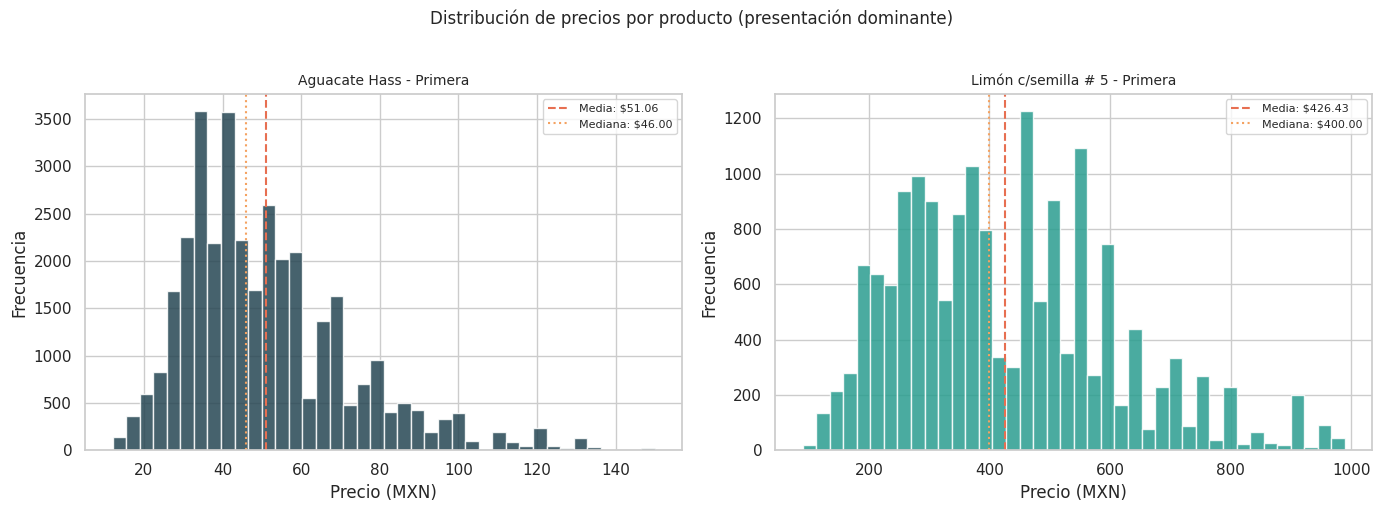

In [32]:
colores = ["#264653", "#2a9d8f"]
fig, axes = plt.subplots(1, len(productos), figsize=(14, 5))
for ax, prod, color in zip(axes, productos, colores):
    vals = df_a[df_a["producto"]==prod]["precio_modelo"].dropna()
    ax.hist(vals, bins=40, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(vals.mean(), color="#e76f51", linestyle="--", linewidth=1.5,
               label=f"Media: ${vals.mean():.2f}")
    ax.axvline(vals.median(), color="#f4a261", linestyle=":", linewidth=1.5,
               label=f"Mediana: ${vals.median():.2f}")
    ax.set_title(prod, fontsize=10)
    ax.set_xlabel("Precio (MXN)")
    ax.set_ylabel("Frecuencia")
    ax.legend(fontsize=8)
plt.suptitle("Distribución de precios por producto (presentación dominante)", y=1.02, fontsize=12)
plt.tight_layout(); plt.show()

## Serie histórica de precios por producto

> Precio promedio mensual. Cada punto es un mes; la línea conecta la evolución histórica de 2016 a 2026.

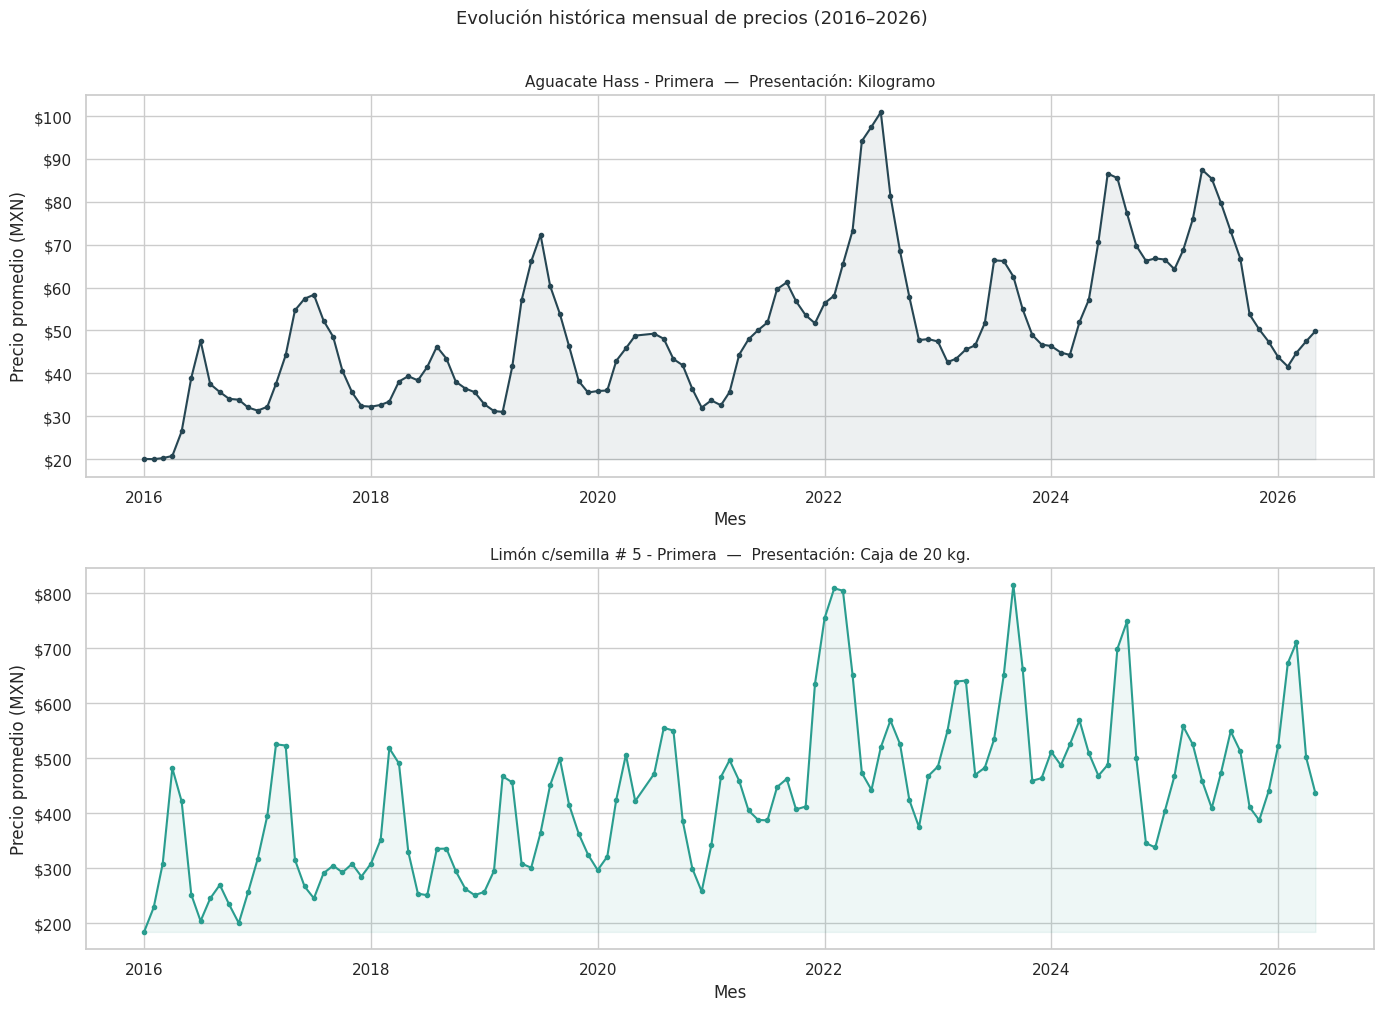

In [33]:
serie_m = (
    df_a.groupby(["anio_mes","producto"], as_index=False)
        .agg(precio_promedio=("precio_modelo","mean"))
)
serie_m["fecha_mes"] = pd.to_datetime(serie_m["anio_mes"] + "-01")

colores_prod = {productos[0]: "#264653", productos[1]: "#2a9d8f"}

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=False)
for ax, prod in zip(axes, productos):
    grp   = serie_m[serie_m["producto"]==prod].sort_values("fecha_mes")
    color = colores_prod.get(prod, "#e76f51")
    ax.plot(grp["fecha_mes"], grp["precio_promedio"],
            marker="o", markersize=3, linewidth=1.5, color=color)
    ax.fill_between(grp["fecha_mes"], grp["precio_promedio"],
                    grp["precio_promedio"].min(), alpha=0.08, color=color)
    ax.set_title(f"{prod}  —  Presentación: {pres_obj(prod)}", fontsize=11)
    ax.set_ylabel("Precio promedio (MXN)")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("$%.0f"))
    ax.set_xlabel("Mes")
plt.suptitle("Evolución histórica mensual de precios (2016–2026)", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

## Top orígenes y destinos

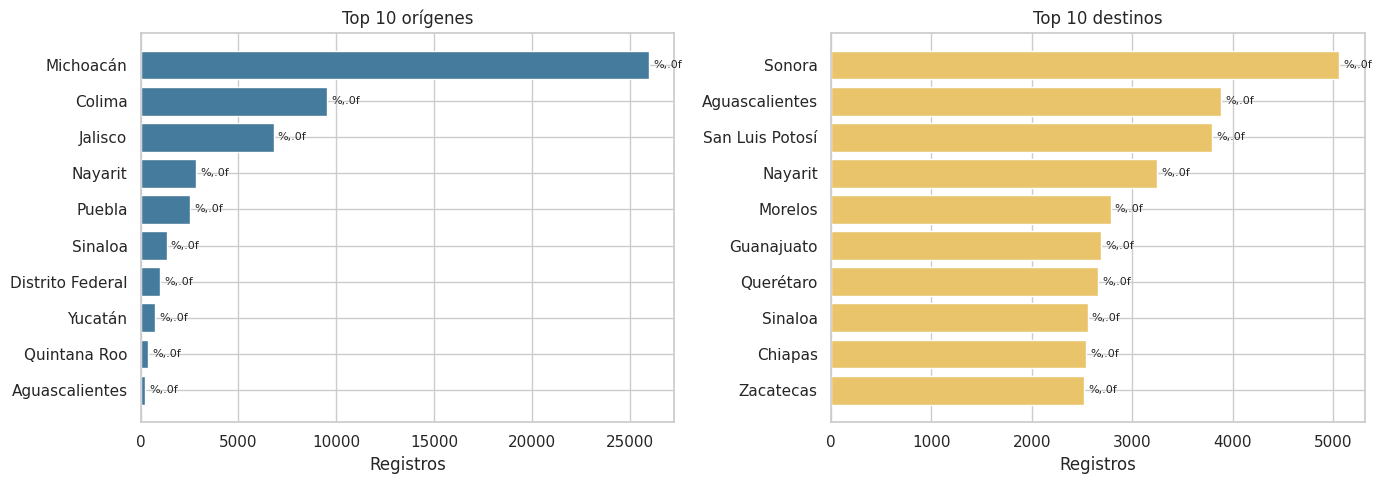

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, color, title in [
    (axes[0], "origen_estado", "#457b9d", "Top 10 orígenes"),
    (axes[1], "destino_estado", "#e9c46a", "Top 10 destinos"),
]:
    tmp = df_a[col].value_counts().head(10).sort_values()
    bars = ax.barh(tmp.index, tmp.values, color=color)
    ax.bar_label(bars, fmt="%,.0f", padding=3, fontsize=8)
    ax.set_title(title); ax.set_xlabel("Registros")
plt.tight_layout(); plt.show()

## Precio promedio por ruta (top 15)

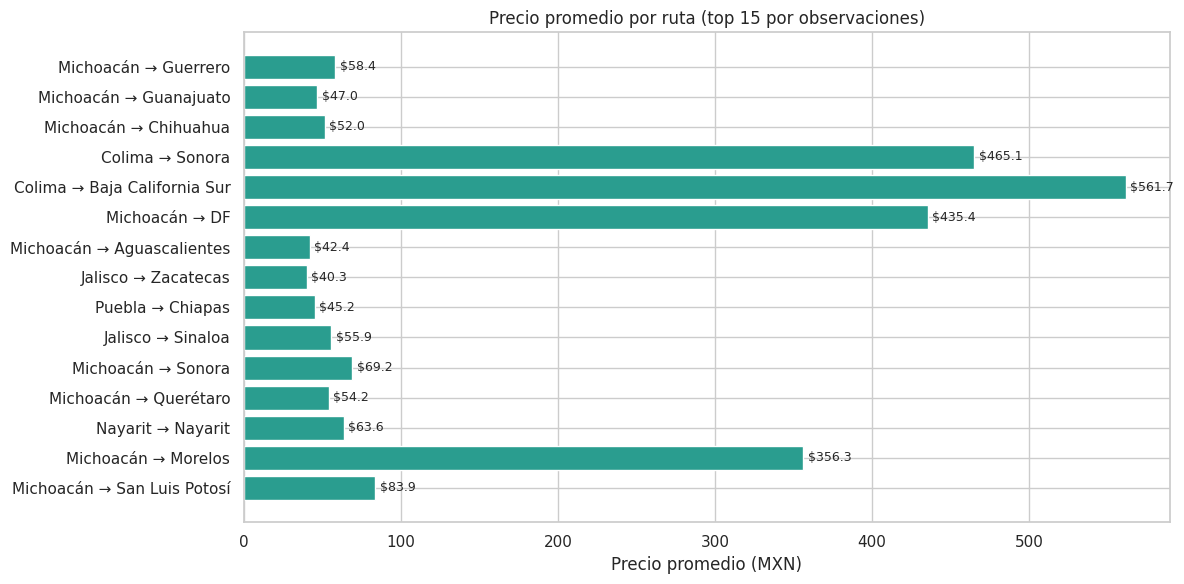

In [35]:
rutas = (
    df_a.groupby(["origen_estado","destino_estado"], as_index=False)
        .agg(precio_prom=("precio_modelo","mean"), obs=("precio_modelo","size"))
        .sort_values("obs", ascending=False).head(15)
)
rutas["ruta"] = rutas["origen_estado"] + " → " + rutas["destino_estado"]
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(rutas["ruta"], rutas["precio_prom"], color="#2a9d8f")
ax.bar_label(bars, fmt="$%.1f", padding=3, fontsize=9)
ax.set_title("Precio promedio por ruta (top 15 por observaciones)", fontsize=12)
ax.set_xlabel("Precio promedio (MXN)")
plt.tight_layout(); plt.show()

---

# Modelos estocásticos — Pronóstico SARIMA {#sec-arima}

> Se usa una **serie mensual** (precio promedio por mes) para capturar la estacionalidad anual. El modelo **SARIMA(1,1,1)(0,1,1,12)** aplica diferenciación estacional de 12 meses, produciendo pronósticos con variación realista — no lineal. Este pronóstico alimenta directamente el modelo de ML.

In [36]:
ORDEN_ARIMA    = (1, 1, 1)
ORDEN_SEASONAL = (0, 1, 1, 12)   # estacionalidad anual (12 meses)

resultados_arima = {}

for prod in productos:
    sub   = df_a[df_a["producto"] == prod]
    serie = (sub.set_index("fecha")["precio_modelo"]
                .resample("MS").mean()
                .interpolate(method="time")
                .ffill().bfill())

    n_test = 12
    train, test = serie.iloc[:-n_test], serie.iloc[-n_test:]

    # Modelo en train → evaluar
    mod_eval = SARIMAX(train, order=ORDEN_ARIMA, seasonal_order=ORDEN_SEASONAL,
                       enforce_stationarity=False,
                       enforce_invertibility=False).fit(disp=False)
    pred_test = mod_eval.get_forecast(steps=n_test)
    pred_mean = pred_test.predicted_mean
    pred_ci   = pred_test.conf_int()

    mae  = float(np.mean(np.abs(test.values - pred_mean.values)))
    rmse = float(np.sqrt(np.mean((test.values - pred_mean.values)**2)))
    mape = float(np.mean(np.abs((test.values - pred_mean.values) / test.values)) * 100)

    # Modelo completo → pronóstico futuro
    mod_full = SARIMAX(serie, order=ORDEN_ARIMA, seasonal_order=ORDEN_SEASONAL,
                       enforce_stationarity=False,
                       enforce_invertibility=False).fit(disp=False)
    fc_fut      = mod_full.get_forecast(steps=HORIZONTE_MESES)
    fc_fut_mean = fc_fut.predicted_mean
    fc_fut_ci   = fc_fut.conf_int()
    fut_idx     = pd.date_range(serie.index[-1] + pd.DateOffset(months=1),
                                periods=HORIZONTE_MESES, freq="MS")
    fc_fut_mean.index = fut_idx
    fc_fut_ci.index   = fut_idx

    resultados_arima[prod] = {
        "serie": serie, "train": train, "test": test,
        "pred_mean": pred_mean, "pred_ci": pred_ci,
        "fc_fut_mean": fc_fut_mean, "fc_fut_ci": fc_fut_ci,
        "precio_futuro": float(fc_fut_mean.mean()),
        "mae": mae, "rmse": rmse, "mape": mape,
    }
    print(f"{'='*55}")
    print(f"Producto : {prod}")
    print(f"Modelo   : SARIMA{ORDEN_ARIMA}{ORDEN_SEASONAL}")
    print(f"Obs. mensuales: {len(serie)}  |  Prueba: {n_test} meses")
    print(f"MAE={mae:.2f}  RMSE={rmse:.2f}  MAPE={mape:.1f}%")
    print(f"Precio prom. pronosticado ({HORIZONTE_MESES}m): ${float(fc_fut_mean.mean()):.2f}")

Producto : Aguacate Hass - Primera
Modelo   : SARIMA(1, 1, 1)(0, 1, 1, 12)
Obs. mensuales: 125  |  Prueba: 12 meses
MAE=30.59  RMSE=31.99  MAPE=60.0%
Precio prom. pronosticado (12m): $42.98
Producto : Limón c/semilla # 5 - Primera
Modelo   : SARIMA(1, 1, 1)(0, 1, 1, 12)
Obs. mensuales: 125  |  Prueba: 12 meses
MAE=73.17  RMSE=87.32  MAPE=14.2%
Precio prom. pronosticado (12m): $518.94


## Prueba de estacionariedad (ADF)

In [37]:
filas = []
for prod in productos:
    s     = resultados_arima[prod]["serie"]
    r_o   = adfuller(s.dropna(), autolag="AIC")
    r_d   = adfuller(s.diff().dropna(), autolag="AIC")
    filas += [
        {"Producto": prod, "Serie": "Original",
         "Estadístico ADF": round(r_o[0],4), "p-valor": round(r_o[1],4),
         "¿Estacionaria (5%)?": "Sí" if r_o[1]<0.05 else "No"},
        {"Producto": prod, "Serie": "Diferenciada (d=1)",
         "Estadístico ADF": round(r_d[0],4), "p-valor": round(r_d[1],4),
         "¿Estacionaria (5%)?": "Sí" if r_d[1]<0.05 else "No"},
    ]
pd.DataFrame(filas)

,Producto,Serie,Estadístico ADF,p-valor,¿Estacionaria (5%)?
0,Aguacate Hass - Primera,Original,-3.5723,0.0063,Sí
1,Aguacate Hass - Primera,Diferenciada (d=1),-6.6564,0.0000,Sí
2,Limón c/semilla # 5 - Primera,Original,-1.3834,0.5902,No
3,Limón c/semilla # 5 - Primera,Diferenciada (d=1),-4.0459,0.0012,Sí


## Métricas de ajuste

In [38]:
pd.DataFrame([
    {"Producto": p,
     "MAE": round(v["mae"],2), "RMSE": round(v["rmse"],2),
     "MAPE (%)": round(v["mape"],1),
     "Precio futuro prom.": f'${v["precio_futuro"]:.2f}'}
    for p, v in resultados_arima.items()
])

,Producto,MAE,RMSE,MAPE (%),Precio futuro prom.
0,Aguacate Hass - Primera,30.59,31.99,60.0,$42.98
1,Limón c/semilla # 5 - Primera,73.17,87.32,14.2,$518.94


## Pronóstico vs. real — evaluación en prueba

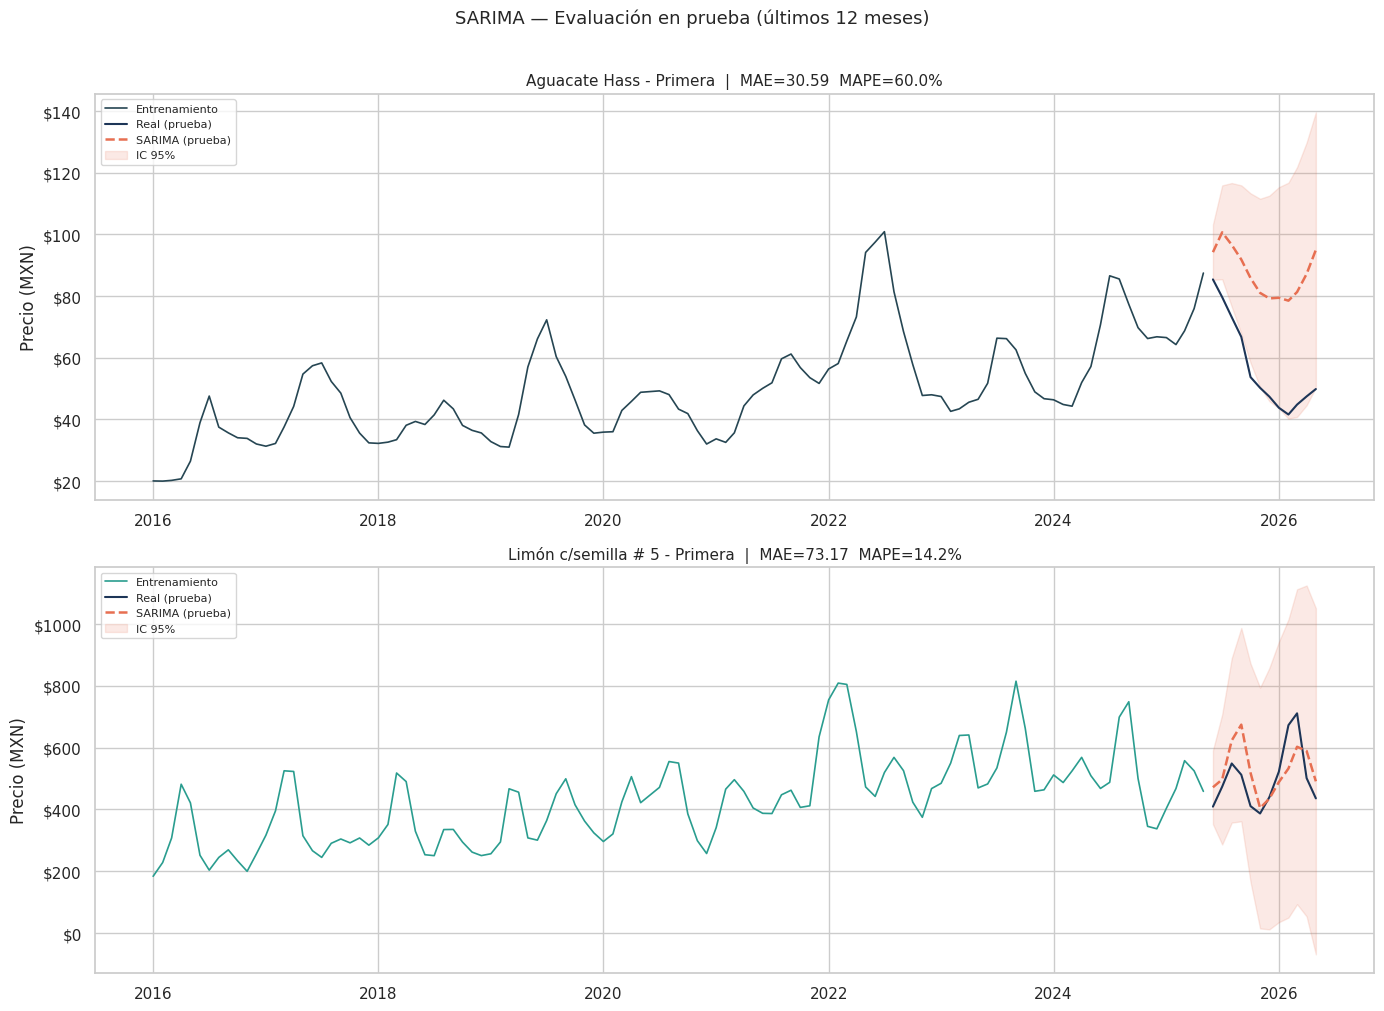

In [39]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
for ax, prod, color in zip(axes, productos, ["#264653","#2a9d8f"]):
    r = resultados_arima[prod]
    ax.plot(r["train"].index, r["train"].values,
            color=color, linewidth=1.2, label="Entrenamiento")
    ax.plot(r["test"].index, r["test"].values,
            color="#1d3557", linewidth=1.5, label="Real (prueba)")
    ax.plot(r["pred_mean"].index, r["pred_mean"].values,
            color="#e76f51", linewidth=1.8, linestyle="--", label="SARIMA (prueba)")
    ax.fill_between(r["pred_ci"].index,
                    r["pred_ci"].iloc[:,0], r["pred_ci"].iloc[:,1],
                    color="#e76f51", alpha=0.15, label="IC 95%")
    ax.set_title(f"{prod}  |  MAE={r['mae']:.2f}  MAPE={r['mape']:.1f}%", fontsize=11)
    ax.set_ylabel("Precio (MXN)"); ax.legend(fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("$%.0f"))
plt.suptitle("SARIMA — Evaluación en prueba (últimos 12 meses)", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

## Pronóstico operativo — próximos  meses

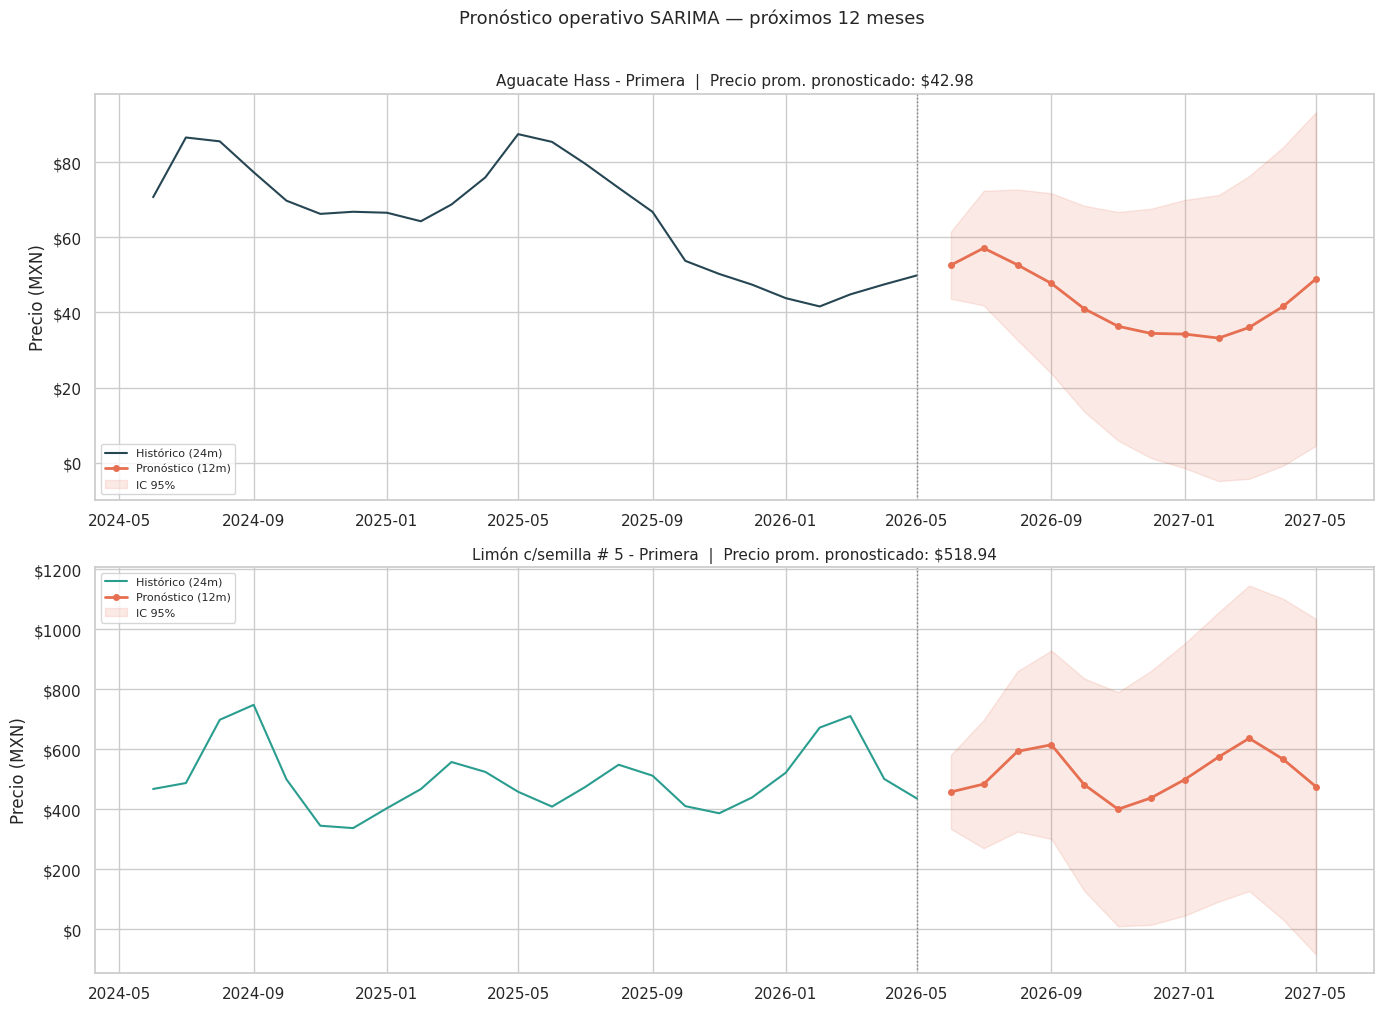

In [40]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
for ax, prod, color in zip(axes, productos, ["#264653","#2a9d8f"]):
    r       = resultados_arima[prod]
    ultimos = r["serie"].iloc[-24:]
    fc_m    = r["fc_fut_mean"]
    fc_ci   = r["fc_fut_ci"]

    ax.plot(ultimos.index, ultimos.values,
            color=color, linewidth=1.5, label="Histórico (24m)")
    ax.plot(fc_m.index, fc_m.values,
            color="#e76f51", linewidth=2, marker="o", markersize=4,
            label=f"Pronóstico ({HORIZONTE_MESES}m)")
    ax.fill_between(fc_ci.index, fc_ci.iloc[:,0], fc_ci.iloc[:,1],
                    color="#e76f51", alpha=0.15, label="IC 95%")
    ax.axvline(r["serie"].index[-1], color="gray", linestyle=":", linewidth=1)
    ax.set_title(
        f"{prod}  |  Precio prom. pronosticado: ${r['precio_futuro']:.2f}", fontsize=11)
    ax.set_ylabel("Precio (MXN)"); ax.legend(fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("$%.0f"))
plt.suptitle(f"Pronóstico operativo SARIMA — próximos {HORIZONTE_MESES} meses",
             fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

---

# Machine Learning — ¿Conviene vender? {#sec-ml}

> El precio pronosticado por SARIMA se usa para calcular el **margen neto estimado** por cada par origen-destino. Un **Árbol de Decisión** aprende cuándo conviene vender y produce la tabla de recomendaciones.

## Regla de negocio

$$
\text{margen neto} = \hat{P}_{\text{SARIMA}} - P_{\text{actual}} - C_{\text{transporte}} - C_{\text{operativo}}
$$

Se recomienda **vender** cuando: $\text{margen neto} \geq$ `MARGEN_MINIMO`

## Construcción del panel

In [41]:
panel_total = []
for prod in productos:
    sub = df_a[df_a["producto"] == prod].copy()
    pf  = resultados_arima[prod]["precio_futuro"]   # ← viene de SARIMA

    sub["precio_pronosticado"] = pf
    sub["precio_actual"]       = sub["precio_modelo"]
    sub["mismo_estado"]        = (
        sub["origen_estado"].apply(norm) == sub["destino_estado"].apply(norm)
    ).astype(int)
    sub["costo_transporte"]    = sub.apply(
        lambda r: costo_trans(r["origen_estado"], r["destino_estado"]), axis=1)
    sub["margen"]              = (pf - sub["precio_actual"]
                                  - sub["costo_transporte"] - COSTO_OPERATIVO)
    sub["vende"]               = (sub["margen"] >= MARGEN_MINIMO).astype(int)
    panel_total.append(sub)

panel = pd.concat(panel_total, ignore_index=True)

print(f"Registros en panel: {len(panel):,}")
print("\nDistribución de la etiqueta 'vende' por producto:")
print(panel.groupby("producto")["vende"].value_counts().unstack().to_string())

Registros en panel: 51,402

Distribución de la etiqueta 'vende' por producto:
vende                              0      1
producto                                   
Aguacate Hass - Primera        20720  13974
Limón c/semilla # 5 - Primera   4800  11908


## Entrenamiento del Árbol de Decisión

In [42]:
FEATS = ["precio_actual","precio_pronosticado","margen",
         "costo_transporte","mismo_estado","mes"]

fechas = panel["fecha"].sort_values().unique()
corte  = fechas[int(len(fechas) * 0.8)]
tr     = panel[panel["fecha"] <= corte]
te     = panel[panel["fecha"] >  corte]

clf = DecisionTreeClassifier(max_depth=4, class_weight="balanced", random_state=42)
clf.fit(tr[FEATS].fillna(0), tr["vende"])
pred = clf.predict(te[FEATS].fillna(0))

pd.DataFrame({
    "Métrica":  ["Accuracy","Precisión","Recall","F1"],
    "Valor": [
        round(accuracy_score(te["vende"], pred), 4),
        round(precision_score(te["vende"], pred, zero_division=0), 4),
        round(recall_score(te["vende"], pred, zero_division=0), 4),
        round(f1_score(te["vende"], pred, zero_division=0), 4),
    ]
})

,Métrica,Valor
0,Accuracy,1.0
1,Precisión,1.0
2,Recall,1.0
3,F1,1.0


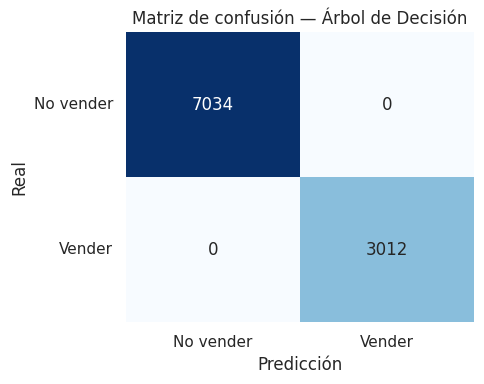

In [43]:
cm = confusion_matrix(te["vende"], pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_xticklabels(["No vender","Vender"])
ax.set_yticklabels(["No vender","Vender"], rotation=0)
ax.set_xlabel("Predicción"); ax.set_ylabel("Real")
ax.set_title("Matriz de confusión — Árbol de Decisión")
plt.tight_layout(); plt.show()

## Estructura del árbol de decisión

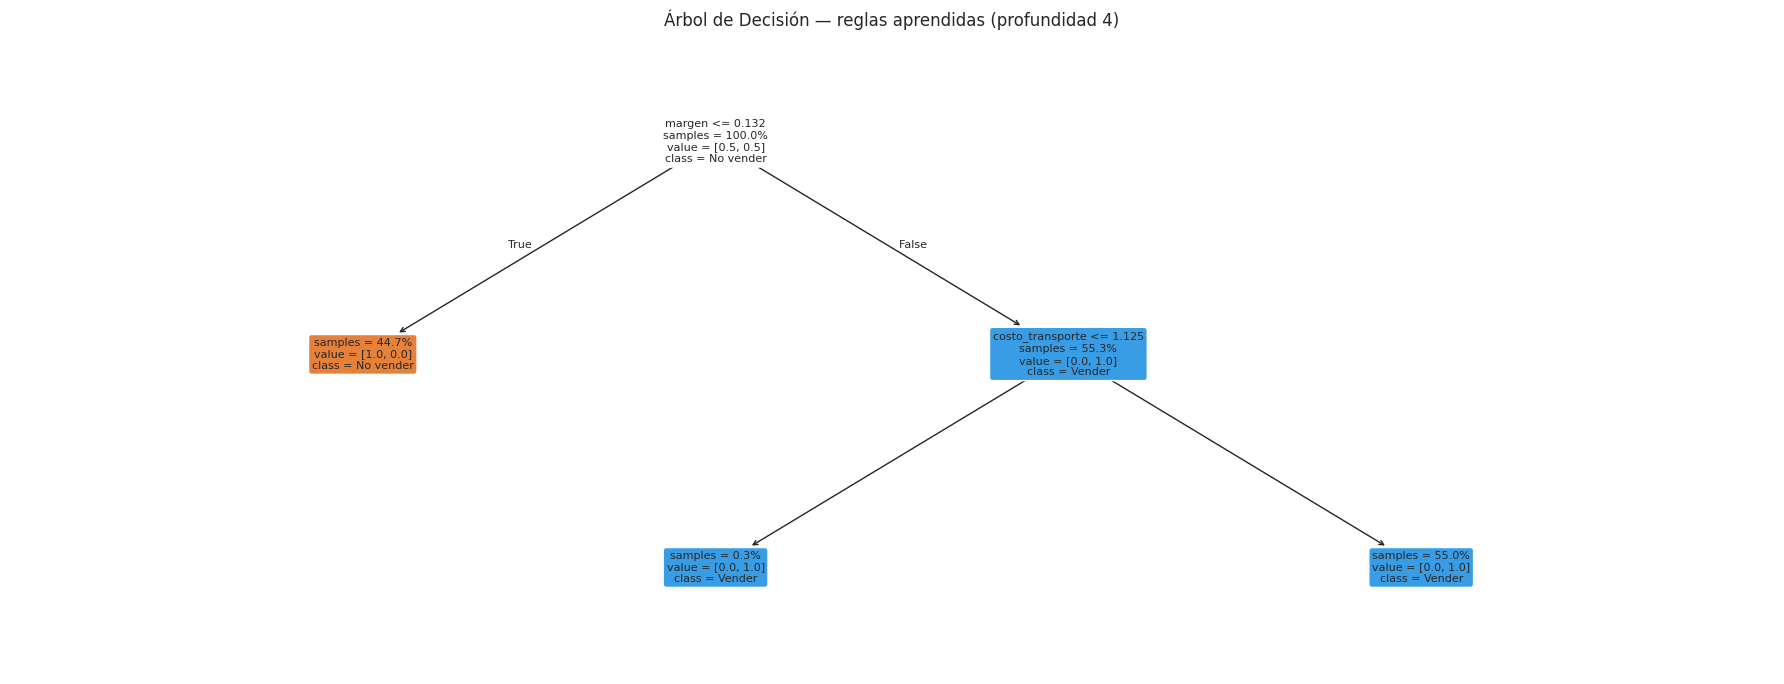

In [44]:
fig, ax = plt.subplots(figsize=(18, 7))
plot_tree(clf, feature_names=FEATS, class_names=["No vender","Vender"],
          filled=True, rounded=True, fontsize=8, ax=ax,
          impurity=False, proportion=True)
ax.set_title("Árbol de Decisión — reglas aprendidas (profundidad 4)", fontsize=12)
plt.tight_layout(); plt.show()

## Tabla de recomendación: Origen × Destino

> **Lectura:** cada fila es un estado de **origen**, cada columna un estado de **destino**. La celda indica si el modelo recomienda vender o no según el pronóstico SARIMA y los costos estimados. Las celdas vacías (—) no tienen observaciones históricas.

In [45]:
panel["pred_vende"] = clf.predict(panel[FEATS].fillna(0))

for prod in productos:
    sub_p = panel[panel["producto"] == prod]
    pivot_num = (
        sub_p.groupby(["origen_estado","destino_estado"])["pred_vende"]
             .agg(lambda s: 1 if s.mean() >= 0.5 else 0)
             .unstack()
    )
    pivot_str = pivot_num.copy().astype(object)
    for r in pivot_str.index:
        for c in pivot_str.columns:
            v = pivot_num.loc[r, c]
            if pd.isna(v):         pivot_str.loc[r, c] = "—"
            elif v == 1:           pivot_str.loc[r, c] = " Vender"
            else:                  pivot_str.loc[r, c] = " No vender"

    print(f"\n{'='*60}")
    print(f"PRODUCTO: {prod}")
    print(f"Precio pronosticado SARIMA (prom. {HORIZONTE_MESES}m): "
          f"${resultados_arima[prod]['precio_futuro']:.2f}")
    print(f"{'='*60}\n")
    display(pivot_str)


PRODUCTO: Aguacate Hass - Primera
Precio pronosticado SARIMA (prom. 12m): $42.98



destino_estado,Aguascalientes,Chiapas,Chihuahua,Colima,Durango,Guanajuato,Guerrero,Morelos,México,Nayarit,Puebla,Querétaro,Quintana Roo,San Luis Potosí,Sinaloa,Sonora,Tabasco,Veracruz,Yucatán,Zacatecas
origen_estado,,,,,,,,,,,,,,,,,,,,
Aguascalientes,Vender,—,—,—,—,—,—,—,—,No vender,—,—,—,—,—,—,—,—,—,Vender
Chiapas,—,—,—,—,No vender,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—
Colima,—,—,—,Vender,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—
Distrito Federal,—,—,—,—,—,—,—,—,—,—,—,—,Vender,—,—,—,—,—,No vender,—
Durango,—,—,—,—,Vender,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—
Jalisco,Vender,—,Vender,No vender,No vender,—,—,—,—,—,—,—,—,—,No vender,—,—,—,—,Vender
Michoacán,Vender,—,No vender,—,Vender,No vender,No vender,No vender,Vender,Vender,—,No vender,—,Vender,No vender,No vender,—,No vender,—,—
México,—,—,No vender,—,—,—,—,—,—,—,—,—,No vender,—,—,—,No vender,—,—,—
Nacional,Vender,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—



PRODUCTO: Limón c/semilla # 5 - Primera
Precio pronosticado SARIMA (prom. 12m): $518.94



destino_estado,Aguascalientes,Baja California Sur,DF,Durango,Guanajuato,Morelos,México,Nuevo León,Querétaro,San Luis Potosí,Sonora
origen_estado,,,,,,,,,,,
Aguascalientes,—,—,—,Vender,—,—,—,—,—,—,—
Colima,Vender,No vender,—,Vender,Vender,—,—,Vender,—,Vender,Vender
Guerrero,—,—,—,—,—,—,—,No vender,—,—,—
Jalisco,—,—,—,Vender,—,—,—,—,—,—,—
Michoacán,—,—,Vender,Vender,—,Vender,Vender,Vender,Vender,Vender,Vender
Veracruz,—,—,—,—,—,Vender,—,—,—,—,—


## Mapa de calor — decisión por ruta

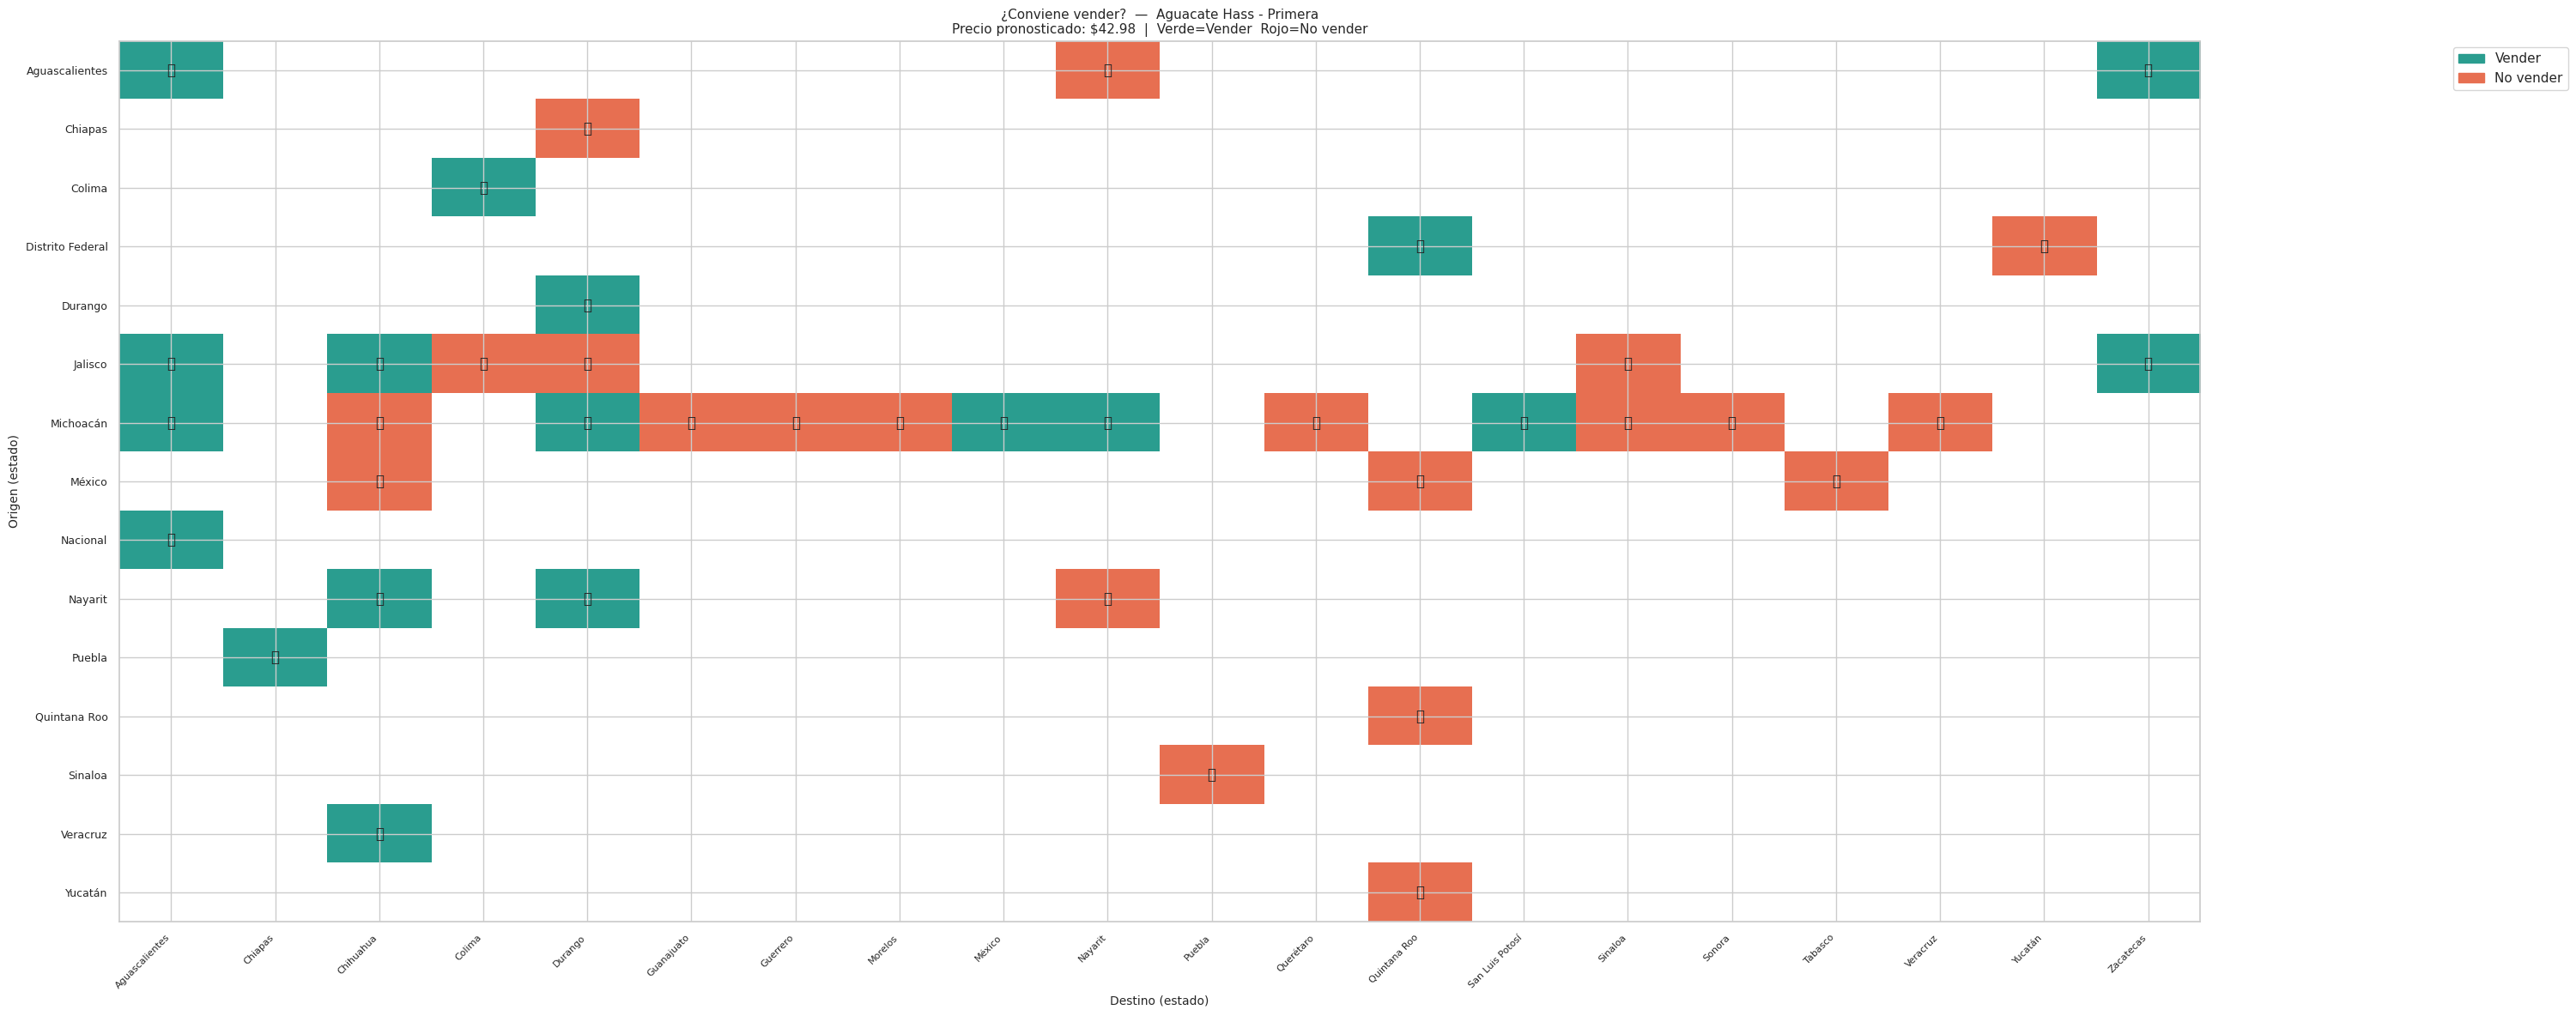

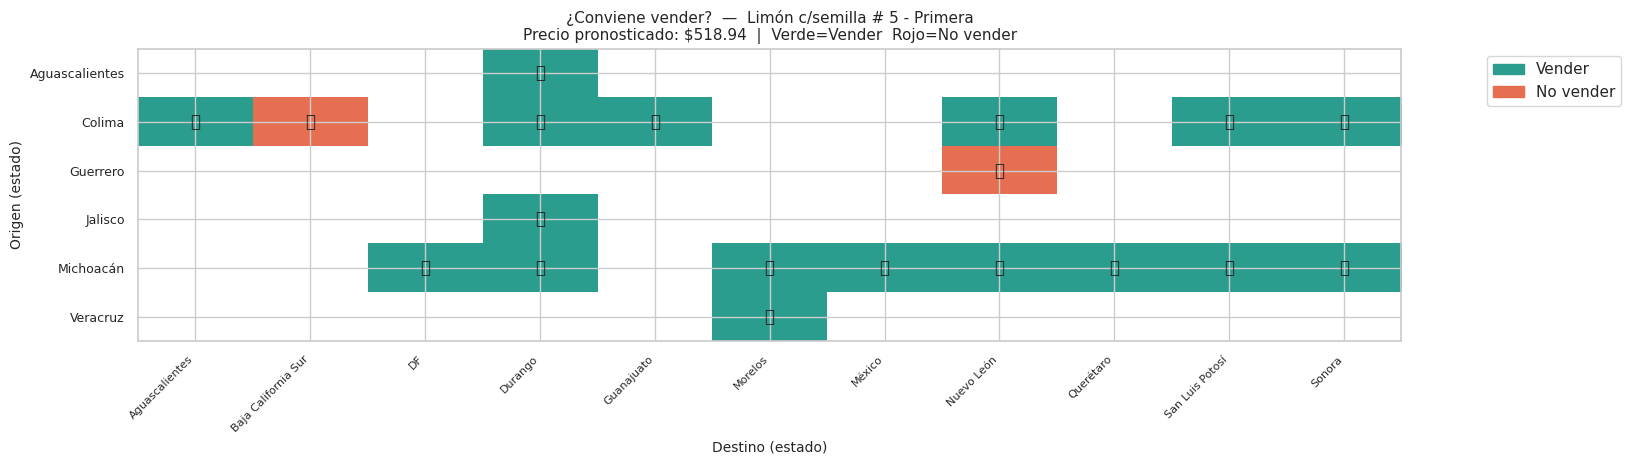

In [53]:
for prod in productos:
    sub_p = panel[panel["producto"] == prod]
    pivot_num = (
        sub_p.groupby(["origen_estado","destino_estado"])["pred_vende"]
             .agg(lambda s: 1 if s.mean() >= 0.5 else 0)
             .unstack()
    )
    vals = pivot_num.values.astype(float)

    fig, ax = plt.subplots(figsize=(max(10, pivot_num.shape[1]*1.5),
                                    max(4,  pivot_num.shape[0]*0.8)))
    cmap   = ListedColormap(["#e76f51","#2a9d8f"])
    masked = np.ma.masked_invalid(vals)
    ax.imshow(masked, cmap=cmap, vmin=0, vmax=1, aspect="auto")

    ax.set_xticks(range(len(pivot_num.columns)))
    ax.set_yticks(range(len(pivot_num.index)))
    ax.set_xticklabels(pivot_num.columns, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(pivot_num.index, fontsize=9)

    for i in range(pivot_num.shape[0]):
        for j in range(pivot_num.shape[1]):
            v = vals[i, j]
            if not np.isnan(v):
                ax.text(j, i, "✅" if v==1 else "❌",
                        ha="center", va="center", fontsize=12)

    ax.set_xlabel("Destino (estado)", fontsize=10)
    ax.set_ylabel("Origen (estado)", fontsize=10)
    ax.set_title(
        f"¿Conviene vender?  —  {prod}\n"
        f"Precio pronosticado: ${resultados_arima[prod]['precio_futuro']:.2f}  "
        f"|  Verde=Vender  Rojo=No vender",
        fontsize=11)
    legend = [Patch(color="#2a9d8f", label="Vender"),
              Patch(color="#e76f51", label="No vender")]
    ax.legend(handles=legend, loc="upper right", bbox_to_anchor=(1.18, 1))
    plt.tight_layout(); plt.show()

---

# Investigación de Operaciones — Transporte con Vogel {#sec-vogel}

> Con las predicciones del árbol de decisión identificamos las rutas convenientes y aplicamos el **método de Vogel** para asignar la distribución del producto minimizando el costo total.

## Formulación

$$\min \sum_i \sum_j c_{ij} \, x_{ij} \quad \text{s.a. oferta y demanda}$$

El costo efectivo se ajusta con la predicción del árbol:
$$c_{ij}^* = c_{ij} \times (1 - 0.15 \times \hat{p}_{ij})$$

In [47]:
def vogel(cost_matrix, supply, demand, row_labels, col_labels):
    C = np.array(cost_matrix, dtype=float)
    s = np.array(supply, dtype=float).copy()
    d = np.array(demand, dtype=float).copy()
    rl, cl = list(row_labels), list(col_labels)

    if not np.isclose(s.sum(), d.sum()):
        if s.sum() > d.sum():
            d = np.append(d, s.sum()-d.sum()); C = np.c_[C, np.zeros(C.shape[0])]; cl.append("Dummy")
        else:
            s = np.append(s, d.sum()-s.sum()); C = np.r_[C, np.zeros((1,C.shape[1]))]; rl.append("Dummy")

    m, n   = C.shape
    alloc  = np.zeros((m, n))
    ar, ac = np.ones(m, bool), np.ones(n, bool)

    while ar.any() and ac.any():
        rp = np.full(m, -np.inf); cp = np.full(n, -np.inf)
        for i in range(m):
            if not ar[i]: continue
            v = C[i, ac]
            rp[i] = np.diff(np.sort(v)[:2])[0] if len(v)>=2 else (v[0] if len(v) else -np.inf)
        for j in range(n):
            if not ac[j]: continue
            v = C[ar, j]
            cp[j] = np.diff(np.sort(v)[:2])[0] if len(v)>=2 else (v[0] if len(v) else -np.inf)
        if np.max(rp) >= np.max(cp):
            i = int(np.argmax(rp)); cols=np.where(ac)[0]; j=cols[np.argmin(C[i,cols])]
        else:
            j = int(np.argmax(cp)); rows=np.where(ar)[0]; i=rows[np.argmin(C[rows,j])]
        q = min(s[i], d[j]); alloc[i,j]=q; s[i]-=q; d[j]-=q
        if np.isclose(s[i],0): ar[i]=False
        if np.isclose(d[j],0): ac[j]=False

    return (pd.DataFrame(alloc, index=rl, columns=cl),
            float((alloc*C).sum()),
            pd.DataFrame(C, index=rl, columns=cl))

## Solución por producto


Producto: Aguacate Hass - Primera
Costo total (unidades relativas): 122.0143

Costos ajustados por ruta:


,nayarit,aguascalientes,sonora,sinaloa,chiapas,Dummy
michoacan,1.1932,1.2298,1.2992,1.3500,1.2684,0.0
jalisco,1.2684,1.2326,1.2684,1.2959,1.2684,0.0
nayarit,0.8899,1.2684,1.2684,1.2684,1.2684,0.0
puebla,1.2684,1.2684,1.2684,1.2684,1.2450,0.0



Asignación (unidades relativas):


,nayarit,aguascalientes,sonora,sinaloa,chiapas,Dummy
michoacan,14.34,21.41,7.71,0.00,18.33,0.00
jalisco,0.00,0.00,10.73,10.27,0.00,0.00
nayarit,9.06,0.00,0.00,0.00,0.00,0.00
puebla,0.00,0.00,0.00,8.14,0.00,0.01


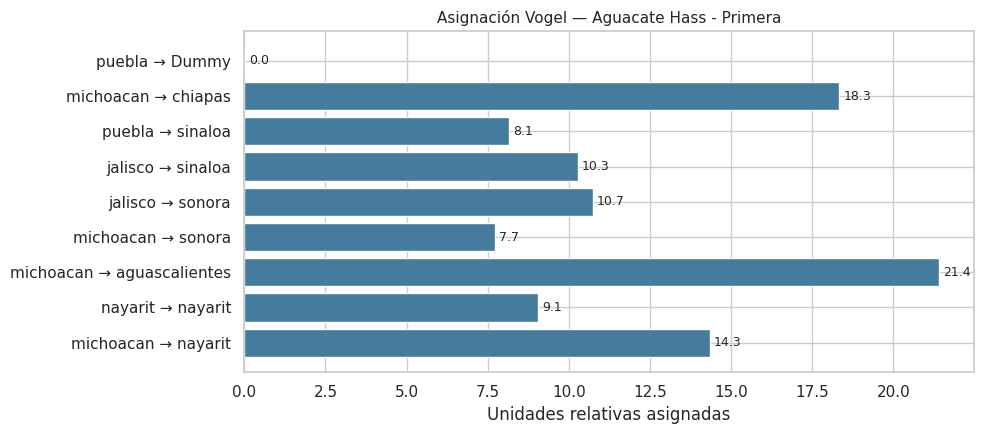


Producto: Limón c/semilla # 5 - Primera
Costo total (unidades relativas): 120.5691

Costos ajustados por ruta:


,sonora,df,baja california sur,nuevo leon,morelos
colima,1.2234,1.2057,1.2668,1.2049,1.2057
michoacan,1.2353,1.2131,1.2057,1.1530,1.1907
jalisco,1.2057,1.2057,1.2057,1.2057,1.2057
aguascalientes,1.2057,1.2057,1.2057,1.2057,1.2057
Dummy,0.0000,0.0000,0.0000,0.0000,0.0000



Asignación (unidades relativas):


,sonora,df,baja california sur,nuevo leon,morelos
colima,20.62,20.4,16.06,0.00,0.00
michoacan,0.00,0.0,1.39,19.91,18.94
jalisco,0.00,0.0,1.48,0.00,0.00
aguascalientes,0.00,0.0,1.19,0.00,0.00
Dummy,0.02,0.0,0.00,0.00,0.00


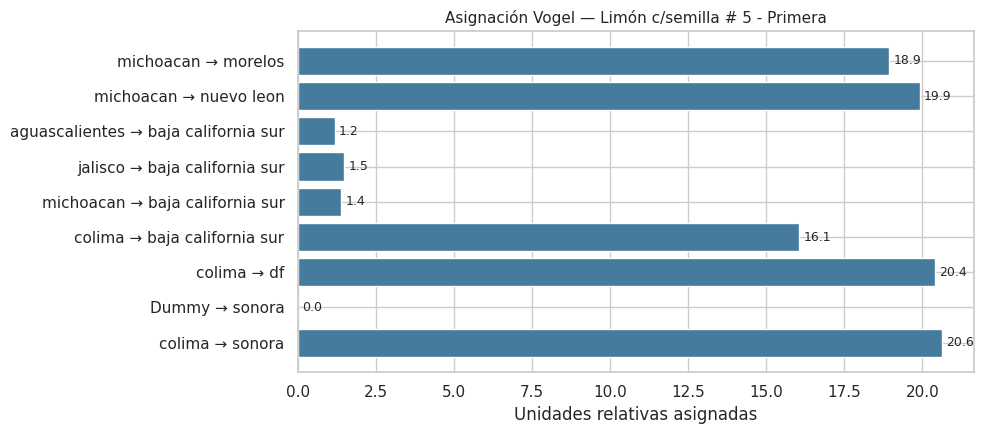

In [48]:
for prod in productos:
    sub_p  = panel[panel["producto"] == prod].copy()
    sub_p["orig_n"] = sub_p["origen_estado"].apply(norm)
    sub_p["dest_n"] = sub_p["destino_estado"].apply(norm)

    orig_top = sub_p.groupby("orig_n").size().sort_values(ascending=False).head(4)
    dest_top = sub_p.groupby("dest_n").size().sort_values(ascending=False).head(5)

    U        = 100.0
    supply_v = (orig_top / orig_top.sum() * U).round(2).values
    demand_v = (dest_top / dest_top.sum() * U).round(2).values

    C = np.zeros((len(orig_top), len(dest_top)))
    for i, o in enumerate(orig_top.index):
        for j, d in enumerate(dest_top.index):
            mask    = (sub_p["orig_n"]==o) & (sub_p["dest_n"]==d)
            p_vende = sub_p.loc[mask,"pred_vende"].mean() if mask.any() else sub_p["pred_vende"].mean()
            C[i,j]  = costo_trans(o, d) * (1 - 0.15 * p_vende)

    alloc_df, costo_total, cost_df = vogel(
        C, supply_v, demand_v, list(orig_top.index), list(dest_top.index))

    print(f"\n{'='*55}")
    print(f"Producto: {prod}")
    print(f"Costo total (unidades relativas): {costo_total:.4f}")
    print("\nCostos ajustados por ruta:")
    display(cost_df.round(4))
    print("\nAsignación (unidades relativas):")
    display(alloc_df)

    det = (alloc_df.reset_index().rename(columns={"index":"origen"})
                   .melt(id_vars="origen", var_name="destino", value_name="asignacion")
                   .query("asignacion > 0").copy())
    det["costo_unitario"] = det.apply(lambda r: cost_df.loc[r["origen"],r["destino"]], axis=1)
    det["costo_ruta"]     = (det["asignacion"] * det["costo_unitario"]).round(4)
    det["ruta"]           = det["origen"] + " → " + det["destino"]

    fig, ax = plt.subplots(figsize=(10, max(3, len(det)*0.5)))
    bars = ax.barh(det["ruta"], det["asignacion"], color="#457b9d")
    ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=9)
    ax.set_title(f"Asignación Vogel — {prod}", fontsize=11)
    ax.set_xlabel("Unidades relativas asignadas")
    plt.tight_layout(); plt.show()

> **Supuestos:** oferta y demanda proporcionales a la frecuencia de observaciones históricas. Costos de flete son proxies parametrizables. La solución de Vogel es una solución inicial factible para optimización logística.

---

# Plan de Marketing Digital {#sec-marketing}

> Las acciones de marketing se activan directamente con los resultados del pipeline: pronóstico favorable → mensaje personalizado → ruta óptima comunicada.

In [49]:
filas_mkt = []
for prod in productos:
    r      = resultados_arima[prod]
    sub_p  = panel[panel["producto"]==prod]
    p_act  = sub_p["precio_actual"].median()
    p_pron = r["precio_futuro"]
    vender_mask = sub_p["pred_vende"]==1
    n_rutas = int((sub_p.groupby(["origen_estado","destino_estado"])["pred_vende"]
                        .mean()>=0.5).sum())
    if vender_mask.any():
        mejor = (sub_p[vender_mask]
                   .groupby(["origen_estado","destino_estado"])["margen"]
                   .mean().idxmax())
        mejor_str = f"{mejor[0]} → {mejor[1]}"
    else:
        mejor_str = "—"
    filas_mkt.append({
        "Producto": prod,
        "Precio actual (med.)": f"${p_act:.2f}",
        "Precio pron. SARIMA": f"${p_pron:.2f}",
        "Mejor ruta": mejor_str,
        "Rutas recomendadas": n_rutas,
    })
pd.DataFrame(filas_mkt)

,Producto,Precio actual (med.),Precio pron. SARIMA,Mejor ruta,Rutas recomendadas
0,Aguacate Hass - Primera,$46.00,$42.98,Nayarit → Durango,18
1,Limón c/semilla # 5 - Primera,$400.00,$518.94,Michoacán → Querétaro,17


## Tabla de acciones

In [50]:
pd.DataFrame({
    "Acción": [
        "Alerta de precio favorable",
        "Mensaje segmentado por ruta",
        "Mapa de rutas recomendadas",
        "Pronóstico mensual",
        "Testimonio de productor",
        "Tablero Quarto actualizado",
    ],
    "Objetivo": [
        "Captar atención del productor",
        "Personalizar la comunicación",
        "Convertir la decisión de venta",
        "Reducir incertidumbre",
        "Generar confianza en el modelo",
        "Sostener seguimiento continuo",
    ],
    "Canal": [
        "WhatsApp Business / Facebook",
        "Email / WhatsApp",
        "Dashboard HTML (este notebook)",
        "Correo electrónico",
        "Redes sociales",
        "Quarto HTML publicado",
    ],
    "Cuándo activar": [
        "Pronóstico > precio actual + costos",
        "Probabilidad de venta > 50%",
        f"Margen estimado > ${MARGEN_MINIMO}",
        "Cada inicio de mes",
        "Al cerrar venta exitosa",
        "Con cada actualización del CSV",
    ],
    "KPI": [
        "Tasa de apertura",
        "Respuestas / clics",
        "Ventas concretadas",
        "Retención mensual",
        "Engagement",
        "Visitas al tablero",
    ]
})

,Acción,Objetivo,Canal,Cuándo activar,KPI
0,Alerta de precio favorable,Captar atención del productor,WhatsApp Business / Facebook,Pronóstico > precio actual + costos,Tasa de apertura
1,Mensaje segmentado por ruta,Personalizar la comunicación,Email / WhatsApp,Probabilidad de venta > 50%,Respuestas / clics
2,Mapa de rutas recomendadas,Convertir la decisión de venta,Dashboard HTML (este notebook),Margen estimado > $0.2,Ventas concretadas
3,Pronóstico mensual,Reducir incertidumbre,Correo electrónico,Cada inicio de mes,Retención mensual
4,Testimonio de productor,Generar confianza en el modelo,Redes sociales,Al cerrar venta exitosa,Engagement
5,Tablero Quarto actualizado,Sostener seguimiento continuo,Quarto HTML publicado,Con cada actualización del CSV,Visitas al tablero


## Mensaje ejemplo — WhatsApp Business

In [51]:
for prod in productos:
    r     = resultados_arima[prod]
    sub_p = panel[panel["producto"]==prod]
    n_v   = int((sub_p.groupby(["origen_estado","destino_estado"])["pred_vende"]
                      .mean()>=0.5).sum())
    mejor = ("—","—")
    if (sub_p["pred_vende"]==1).any():
        mejor = (sub_p[sub_p["pred_vende"]==1]
                   .groupby(["origen_estado","destino_estado"])["margen"]
                   .mean().idxmax())
    print(f"""
{'─'*55}
 ALERTA MERCADO JUSTO — {prod}
{'─'*55}
 Pronóstico próximos {HORIZONTE_MESES} meses (SARIMA):
   Precio actual referencia : ${sub_p['precio_actual'].median():.2f}
   Precio pronosticado      : ${r['precio_futuro']:.2f}

 Rutas convenientes detectadas : {n_v}
 Mejor ruta : {mejor[0]} → {mejor[1]}

Consulta la tabla completa de rutas en el tablero.
{'─'*55}
""")


───────────────────────────────────────────────────────
 ALERTA MERCADO JUSTO — Aguacate Hass - Primera
───────────────────────────────────────────────────────
 Pronóstico próximos 12 meses (SARIMA):
   Precio actual referencia : $46.00
   Precio pronosticado      : $42.98

 Rutas convenientes detectadas : 18
 Mejor ruta : Nayarit → Durango

Consulta la tabla completa de rutas en el tablero.
───────────────────────────────────────────────────────


───────────────────────────────────────────────────────
 ALERTA MERCADO JUSTO — Limón c/semilla # 5 - Primera
───────────────────────────────────────────────────────
 Pronóstico próximos 12 meses (SARIMA):
   Precio actual referencia : $400.00
   Precio pronosticado      : $518.94

 Rutas convenientes detectadas : 17
 Mejor ruta : Michoacán → Querétaro

Consulta la tabla completa de rutas en el tablero.
───────────────────────────────────────────────────────



---

# Conclusiones

El pipeline conecta cinco etapas donde la salida de cada una alimenta a la siguiente:

| Etapa | Herramienta | Salida para la siguiente etapa |
|---|---|---|
| **EDA** | Estadísticos + gráficas históricas | Serie mensual limpia por producto |
| **SARIMA** | Modelo estocástico estacional | Precio pronosticado por producto |
| **Árbol de Decisión** | ML supervisado | Tabla Origen × Destino (vender / no vender) |
| **Vogel** | Método de transporte | Asignación óptima de unidades por ruta |
| **Marketing** | Plan accionable | Mensajes y alertas basadas en datos |

**Decisiones técnicas clave:**

- **Serie mensual:** elimina ruido diario y permite capturar estacionalidad anual con 125 observaciones.
- **SARIMA(1,1,1)(0,1,1,12):** la diferenciación estacional produce pronósticos con variación realista, no lineal.
- **Árbol de Decisión:** produce reglas interpretables visualmente; la tabla origen × destino convierte el modelo en herramienta de decisión directa.
- **Vogel ajustado por ML:** el costo de transporte se reduce proporcionalmente a la probabilidad de venta predicha.

**Limitaciones:**

- Costos de flete son proxies; validar con cotizaciones reales para uso operativo.
- Oferta/demanda en Vogel son proporcionales a frecuencia; datos de volumen real mejorarían el modelo.
- SARIMA no captura choques externos (clima, precios internacionales); podrían incorporarse como variables exógenas (SARIMAX).